Karttanäkymä, joka näytttä top-10 kaupungit kartalla. Mentäessä sinisen palluran päälle, näyttää kaupungin nimen ja onnettomuuksien määrän.  

In [1]:
import sys
sys.executable


'c:\\Users\\serko\\anaconda3\\envs\\pyspark_env\\python.exe'

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Big").getOrCreate()

df = spark.read.csv("C:/Users/serko/US_Accidents/US_Accidents_March23.csv", header=True, inferSchema=True)

sample_df = df.limit(100000)
sample_df.cache()
#sample_df.printSchema()
sample_df.count()

100000

Top10 kaupungeista, joissa eniten onnettomuuksia koko aineistosta visualisoituna

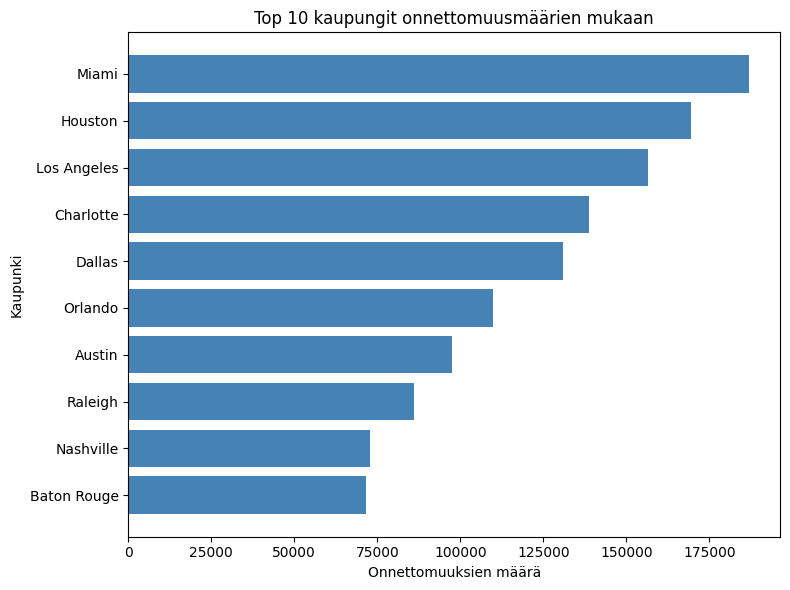

In [3]:
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

top10_dict = {
    row["City"]: row["count"]
    for row in (
        df.groupBy("City")
          .count()
          .orderBy(col("count").desc())
          .limit(10)
          .collect()
    )
}

top10_dict

# visualisointi
cities = list(top10_dict.keys())
counts = list(top10_dict.values())

plt.figure(figsize=(8, 6))
plt.barh(cities, counts, color="steelblue")

plt.title("Top 10 kaupungit onnettomuusmäärien mukaan")
plt.xlabel("Onnettomuuksien määrä")
plt.ylabel("Kaupunki")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Luodaan karttanäkymä, joka näyttää 10 eniten onnettomuuksia sisältänyttä kaupunkia ja tehdään aggregaatti eli näyttää kartalla vain 10 pistettä. 

In [9]:
from pyspark.sql.functions import col, avg, first

top10_df = (
    df.groupBy("City")
      .count()
      .orderBy(col("count").desc())
      .limit(10)
)

# Liitetään koordinaatit ja lasketaan keskiarvot
top10_agg = (
    df.join(top10_df, on="City", how="inner")
      .groupBy("City")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng"),
          first("count").alias("count")
      )
      .withColumnRenamed("City", "City")
      .orderBy(col("count").desc())
      .toPandas()
)


In [14]:
import folium
from folium.plugins import MarkerCluster


# Keskitetään kartta USA:n keskelle
m = folium.Map(location=[39.5, -98.35], zoom_start=4)

# karttanäkymän väri
city_color = {row["City"]: "blue" for _, row in top10_agg.iterrows()}

for i, row in top10_agg.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color=city_color[row["City"]],
        fill=True,
        fill_opacity=0.8,
        popup=f"City: {row['City']}<br>Accidents: {row['count']}"
    ).add_to(m)



In [7]:
m.save("top10_cities_map.html")
m

In [15]:
import webbrowser
webbrowser.open("top10_cities_map.html")

True

Toinen karttaversio, joka näyttää top-10 kaupungeista ja vakavista liikenneonnettomuuksista (severity 3 ja 4)

In [2]:
from pyspark.sql.functions import col, avg, count

# 1. Suodatetaan vain severity 3 ja 4
df_severe = df.filter(col("Severity").isin(3, 4))

# 2. Lasketaan top 10 kaupunkia vakavista onnettomuuksista
sev_top10_df = (
    df_severe.groupBy("City")
      .agg(count("*").alias("accident_count"))
      .orderBy(col("accident_count").desc())
      .limit(10)
)

# 3. Lasketaan koordinaattien keskiarvot ja liitetään mukaan count
sev_top10_agg = (
    df_severe.join(sev_top10_df, on="City", how="inner")
      .groupBy("City", "accident_count")
      .agg(
          avg("Start_Lat").alias("lat"),
          avg("Start_Lng").alias("lng")
      )
      .orderBy(col("accident_count").desc())
      .toPandas()
)


In [ ]:
import folium

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

for i, row in sev_top10_agg.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"City: {row['City']}<br>Severity 3–4 accidents: {row['accident_count']}",
        tooltip=f"{row['City']} – {row['accident_count']} severe accidents"
    ).add_to(m)


m



In [8]:
from IPython.display import display

# Valitaan vain kaupungin nimi ja onnettomuusmäärä
sev_top10_table = sev_top10_agg[["City", "accident_count"]]

# Näytetään taulukko
display(sev_top10_table)

# Näytetään kartta
m


,City,accident_count
0,Los Angeles,35866
1,Dallas,34223
2,Atlanta,33861
3,Houston,30521
4,Chicago,18867
5,Miami,16842
6,Jacksonville,16065
7,Denver,12577
8,Minneapolis,12457
9,San Diego,12131


In [9]:
import folium
from folium.features import DivIcon

m = folium.Map(location=[39.5, -98.35], zoom_start=4)

for i, row in sev_top10_agg.iterrows():
    # Piirretään piste
    folium.CircleMarker(
        location=[row["lat"], row["lng"]],
        radius=10,
        color="red",
        fill=True,
        fill_opacity=0.8
    ).add_to(m)

    # Lisätään tekstilabel
    folium.map.Marker(
        [row["lat"], row["lng"]],
        icon=DivIcon(
            icon_size=(150, 36),
            icon_anchor=(0, 0),
            html=f'<div style="font-size: 12px; color: black;"><b>{row["City"]}: {row["accident_count"]}</b></div>',
        )
    ).add_to(m)

m


In [6]:
m.save("severe_top10_map.html")


In [10]:
import webbrowser
webbrowser.open("severe_top10_map.html")

True

Etsitään vuoden 2020 aineistosta vakavuuden 3,4 onnettomuudet sekä kaupungit, missä ne tapahtuivat. 
Poistetaan mahdolliset duplikaatit, mikäli tällaisia aineistossa on. Duplikaatin ajatellaan olevan kyseessä, jos eri ID, mutta sama Start_Lat, sama Start_Lng js Start_Time 60 sekunnin sisällä. 

In [1]:
from pyspark.sql.functions import col, year, month
from all_dataframes import load_base_df, create_time_df, create_geo_df
import matplotlib.pyplot as plt
import pandas as pd


# Koko datasetin ja haluttujen dataframejen lataus
df = load_base_df("C:/Users/serko/US_ACCIDENTS/US_Accidents_March23.csv")

time_df = create_time_df(df)

geo_df = create_geo_df(df)


all_dataframes.py loaded successfully
Base DataFrame loaded.

time_df created.

geo_df created.


In [2]:
print("Top 20 koordinaattipistettä onnettomuusmäärän mukaan:")
(
    df.groupBy("Start_Lat", "Start_Lng")
      .count()
      .orderBy(col("count").desc())
      .show(20, truncate=False)
)


Top 20 koordinaattipistettä onnettomuusmäärän mukaan:
+------------------+-------------------+-----+
|Start_Lat         |Start_Lng          |count|
+------------------+-------------------+-----+
|37.808498         |-122.36685200000001|570  |
|33.941364         |-118.09663400000001|561  |
|34.858849         |-82.26042199999998 |543  |
|42.476501         |-83.11179399999997 |534  |
|33.744976         |-84.390343         |530  |
|34.858925         |-82.259857         |494  |
|40.847923         |-73.942825         |473  |
|25.789072         |-80.204353         |439  |
|42.368423         |-83.058128         |435  |
|25.89917          |-80.210114         |432  |
|33.781532         |-84.390869         |428  |
|33.876289         |-118.102577        |420  |
|40.850066999999996|-73.944817         |418  |
|34.914188         |-82.10717          |416  |
|33.821548         |-84.359383         |405  |
|25.96417000000001 |-80.16585500000002 |402  |
|34.833031         |-82.296837         |390  |
|33.94

In [3]:
from pyspark.sql.functions import unix_timestamp
from pyspark.sql.window import Window
from pyspark.sql.functions import lag


#  Aikaleimat sekunteina ja aikaeron laskeminen edelliseen tapahtumaan
df2 = df.withColumn("ts", unix_timestamp("Start_Time"))

w = Window.partitionBy("Start_Lat", "Start_Lng").orderBy("ts")

df_with_prev = (
    df2
    .withColumn("prev_ts", lag("ts").over(w))
    .withColumn("time_diff_sec", col("ts") - col("prev_ts"))
)

# Mahdollisten duplikaatit suodatus ja näyttö
possible_duplicates = df_with_prev.filter(
    (col("time_diff_sec") >= 0) & (col("time_diff_sec") <= 120)
)

print("Mahdolliset duplikaatit:")
possible_duplicates.select(
    "ID",
    "Start_Time",
    "prev_ts",
    "time_diff_sec",
    "Start_Lat",
    "Start_Lng",
    "City"

).show(10, truncate=False)


# Poistetaan duplikaatit ja näytetään puhdistettu data
df_clean = df.join(possible_duplicates.select("ID"), on="ID", how="left_anti")

print("Puhdistettu data (ei duplikaatteja):")
df_clean.show(10, truncate=False)



Mahdolliset duplikaatit:
+---------+-------------------+----------+-------------+-----------+------------+------------+
|ID       |Start_Time         |prev_ts   |time_diff_sec|Start_Lat  |Start_Lng   |City        |
+---------+-------------------+----------+-------------+-----------+------------+------------+
|A-4738319|2022-04-16 00:50:00|1650059400|0            |24.928076  |-80.623798  |Islamorada  |
|A-6870527|2020-12-11 17:11:00|1607699460|0            |25.010744  |-80.515575  |Tavernier   |
|A-5197982|2022-07-16 16:25:00|1657977900|0            |25.197402  |-80.416375  |Key Largo   |
|A-6908323|2020-12-22 13:22:30|1608636150|0            |25.439905  |-80.474961  |Homestead   |
|A-6883295|2020-09-20 23:10:33|1600632633|0            |25.447736  |-80.485336  |Homestead   |
|A-6858144|2020-11-23 03:39:30|1606095570|0            |25.447802  |-80.491357  |Homestead   |
|A-3613060|2017-05-08 14:47:47|1494244067|0            |25.44785   |-80.48533   |Florida City|
|A-4206379|2023-01-14 16:

In [4]:
print("Rivimäärä ennen puhdistusta:", df.count())
print("Rivimäärä puhdistuksen jälkeen:", df_clean.count())




Rivimäärä ennen puhdistusta: 7728394
Rivimäärä puhdistuksen jälkeen: 7162203


In [5]:
# Luodaan uudet Spark DataFramet puhdistetusta datasta

df = df_clean

time_df = create_time_df(df)
geo_df = create_geo_df(df)


# Liitä Severity, City, Start_Lat ja Start_Lng mukaan time_df:ään
time_enriched = (
    time_df
    .join(df.select("ID", "Severity", "City"), on="ID", how="left")
    .join(geo_df.select("ID", "Start_Lat", "Start_Lng"), on="ID", how="left")
)

# Suodattaa vakavat onnettomuudet vuodelta 2020 ja laskee vakavat onnettomuudet 
# severity 3,4 kaupunkikohtaisesti 
severe_2020 = (
    time_enriched
    .filter(col("Severity").isin(3, 4))
    .filter(year("Start_Time") == 2020)
)

city_totals = (
    severe_2020
    .groupBy("City")
    .count()
    .orderBy(col("count").desc())
)

# 10 kaupunkia taulukkoon 
top10_cities = city_totals.limit(10).select("City")

monthly_city_counts_top10 = (
    severe_2020
    .withColumn("month", month("Start_Time"))
    .join(top10_cities, on="City", how="inner")
    .groupBy("City", "month")
    .count()
    .orderBy("City", "month")
)

print("Top 10 kaupungin kuukausikohtaiset määrät (Spark-taulukko):")
monthly_city_counts_top10.show(200, truncate=False)

# top 7 kaupungit
top5_cities = city_totals.limit(7).select("City")

# Laskee vakavat onnettomuudet per kuukausi näille kaupungeille 
monthly_city_counts = (
    severe_2020
    .withColumn("month", month("Start_Time"))
    .join(top5_cities, on="City", how="inner")
    .groupBy("City", "month")
    .count()
)

# muunto pandasiksi visualisointia varten
pdf = monthly_city_counts.toPandas()

# visualisointi
plt.figure(figsize=(12, 6))

for city in sorted(pdf["City"].unique()):
    subset = pdf[pdf["City"] == city].sort_values("month")
    plt.plot(subset["month"], subset["count"], marker="o", label=city)

plt.title("Severe Accidents (Severity 3–4) per Month in 2020 – Top 7 Cities")
plt.xlabel("Month")
plt.ylabel("Number of Severe Accidents")
plt.xticks(range(1, 13))
plt.legend(title="City")
plt.grid(True)
plt.show()



time_df created.

geo_df created.
Top 10 kaupungin kuukausikohtaiset määrät (Spark-taulukko):


ConnectionRefusedError: [WinError 10061] Yhteyttä ei voi muodostaa, koska kohdekone ei salli sitä

In [8]:
from pyspark.sql.functions import col, year

severe_2020 = (
    time_enriched
    .filter(col("Severity").isin(3, 4))
    .filter(year("Start_Time") == 2020)
)

city_totals = (
    severe_2020
    .groupBy("City")
    .count()
    .orderBy(col("count").desc())
)

top10_cities = city_totals.limit(10)


In [9]:
top10_geo = (
    top10_cities
    .join(
        geo_df.select("City", "Start_Lat", "Start_Lng").dropDuplicates(["City"]),
        on="City",
        how="left"
    )
)
pdf = top10_geo.toPandas()


In [11]:
import folium

# Kartan keskipiste (USA)
top10_map2020= folium.Map(location=[37.0, -95.0], zoom_start=4)

for _, row in pdf.iterrows():
    city = row["City"]
    lat = row["Start_Lat"]
    lng = row["Start_Lng"]
    count_val = row["count"]

    if lat is None or lng is None:
        continue

    folium.CircleMarker(
        location=[lat, lng],
        radius=6,
        color="red",
        fill=True,
        fill_opacity=0.7,
        popup=f"{city}: {count_val} severe accidents (2020)"
    ).add_to(top10_map2020)

top10_map2020
